# 01 - Pirate LoRA toy (SmolLM2-360M-Instruct)

Learn LoRA by doing: take an open-weight instruct model, teach it pirate speak with a Low-Rank Adapter, and *see* the difference.

Pipeline in this notebook:

1. **Env check** (§0) - torch/HIP, precision decision
2. **Data** (§1) - `quill-voice/pirate`, 90/10 split, 5 holdout prompts
3. **Before + r=8 run** (§2) - baseline samples, first adapter
4. **r=32 run + compare + merge** (§3) - rank sweep, curves, `merge_and_unload`
5. **More epochs** (§4) - does style just need time? verdict + done checklist

How we work: read the explanation above each code cell *before* running it. If a cell surprises you, stop and ask - that surprise is the lesson.

## 0. Environment: why torch comes from AMD, not PyPI

PyPI `torch` wheels are CUDA/CPU-only - on our RX 7900 XTX (gfx1100) `torch.cuda.is_available()` would be `False` with them. So we install torch from AMD's wheel index (pinned in `scripts/install-rocm-torch.sh`). Run the cell below to prove the venv sees the GPU. If it prints the CPU fallback instead, re-run that script - everything after this cell assumes the printed precision decision (`bf16` on HIP, `fp32` on CPU).

In [1]:
import os

# Hide the tiny Raphael iGPU (see scripts/pirate_lora.py header): with two
# visible devices Trainer would DataParallel onto it and segfault.
os.environ.setdefault("HIP_VISIBLE_DEVICES", "0")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import platform
import torch
import matplotlib

print(f"python: {platform.python_version()}")
print(f"torch: {torch.__version__}")
hip = torch.cuda.is_available()
print(f"hip_available: {hip}")
if hip:
    print(f"device_count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"device[{i}]: {torch.cuda.get_device_name(i)}")
    use_bf16 = torch.cuda.is_bf16_supported()
else:
    print("device: CPU (fallback - see scripts/install-rocm-torch.sh)")
    use_bf16 = False
print(f"matplotlib: {matplotlib.__version__}")
print("precision decision:", "bf16" if use_bf16 else "fp32")

python: 3.14.2
torch: 2.10.0+rocm7.13.0
hip_available: True
device_count: 1
device[0]: AMD Radeon RX 7900 XTX
matplotlib: 3.11.2
precision decision: bf16


## 0b. Plotting smoke test

Later sections plot train/val loss, learning-rate schedule, and grad-norm with `matplotlib`. This cell proves plotting works in your setup - expect a sine wave, nothing more.

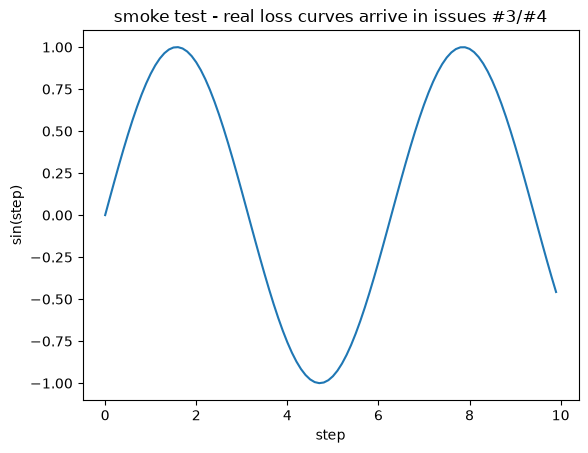

In [2]:
import math
import matplotlib.pyplot as plt

xs = [i / 10 for i in range(100)]
ys = [math.sin(x) for x in xs]
plt.figure()
plt.plot(xs, ys)
plt.title("smoke test - real loss curves arrive in issues #3/#4")
plt.xlabel("step")
plt.ylabel("sin(step)")
plt.show()

## 1. Data: pirate rows, frozen split

`quill-voice/pirate` is 797 `(instruction -> pirate output)` rows - e.g. "Write a Python function..." answered in pirate voice. Two decisions matter here:

1. **Holdouts are excluded from train AND val.** Five prompts are frozen in `data/holdouts.json` as pure demo material. If they stayed in train, the "after" samples in issues #3/#4 would partly be memorization, not style learning. Style is global so 5 rows change nothing measurable - but the habit (never eval on train) is the point.
2. **Split is seeded (42) and re-asserted.** Every LoRA run (r=8, r=32, and the 3-epoch pair) must see identical train/val, or comparisons are meaningless. `scripts/prepare_data.py` froze the counts in `data/split.json`; the cell below re-does the split and asserts equality - rerun it any time to prove reproducibility.

In [3]:
import json
from pathlib import Path
from datasets import load_dataset

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
split_info = json.loads((DATA_DIR / "split.json").read_text())
holdouts = json.loads((DATA_DIR / "holdouts.json").read_text())
print(split_info)

ds = load_dataset(split_info["dataset"], split="train")
assert len(ds) == split_info["total_n"], "dataset changed upstream!"
by_instr = {r["instruction"] for r in ds}
assert all(h in by_instr for h in holdouts), "a holdout is not in the dataset verbatim"

HOLD = set(holdouts)
pool = ds.filter(lambda r: r["instruction"] not in HOLD)
parts = pool.train_test_split(test_size=0.1, seed=split_info["seed"])
train, val = parts["train"], parts["test"]
assert (len(train), len(val)) == (split_info["train_n"], split_info["val_n"])
print(f"train: {len(train)} | val: {len(val)} | holdouts: {len(holdouts)} (in neither)")
print("holdout prompts:")
for h in holdouts:
    print(" -", h)

{'dataset': 'quill-voice/pirate', 'seed': 42, 'test_size': 0.1, 'train_n': 712, 'val_n': 80, 'holdout_n': 5, 'total_n': 797}
train: 712 | val: 80 | holdouts: 5 (in neither)
holdout prompts:
 - Implement SQL query circuit breaker.
 - HTML entity for copyright symbol.
 - What is 220 divided by 22?
 - What is parasitism?
 - What is ablation?


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


### Tokenization: ChatML + assistant-only labels

Two steps, kept visible on purpose: **format** (`apply_chat_template`, ChatML with `<|im_start|>`) then **tokenize**. Note `transformers>=5` returns a `BatchEncoding` dict here, not a bare id list - hence `["input_ids"]`.

The key idea is `labels`: we mask every token up to the assistant's answer with `-100` (PyTorch's "ignore this position" id). We only want to teach *pirate answers*, not pirate questions - without masking, the loss would also reward memorizing user prompts. The prefix boundary is exact (verified: prefix tokenizes identically inside the full sequence on all 797 rows), and nothing exceeds 512 tokens, so `truncation=True` is pure safety.

In [4]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct")

def format_row(instruction, output):
    return tok.apply_chat_template(
        [{"role": "user", "content": instruction},
         {"role": "assistant", "content": output}],
        tokenize=False,
    )

def tokenize_row(instruction, output, max_length=512):
    prefix = tok.apply_chat_template(
        [{"role": "user", "content": instruction}],
        tokenize=False, add_generation_prompt=True,
    )
    full = format_row(instruction, output)
    input_ids = tok(full, truncation=True, max_length=max_length)["input_ids"]
    pre_len = len(tok(prefix, truncation=True, max_length=max_length)["input_ids"])
    pre_len = min(pre_len, len(input_ids))
    labels = [-100] * pre_len + input_ids[pre_len:]
    return input_ids, labels

print("3 tokenized samples (instruction | ids | supervised positions):")
for i in [0, 1, 2]:
    r = train[i]
    ids, labels = tokenize_row(r["instruction"], r["output"])
    kept = sum(l != -100 for l in labels)
    print(f"[{i}] {r['instruction'][:60]!r} | ids={len(ids)} | supervised={kept}")
    assert kept > 0 and len(ids) <= 512

3 tokenized samples (instruction | ids | supervised positions):
[0] 'What is hoarfrost?' | ids=64 | supervised=28
[1] 'What is 6 times 9?' | ids=59 | supervised=21
[2] 'Why did pirates wear eye patches?' | ids=71 | supervised=34


In [5]:
lens = [len(tokenize_row(r["instruction"], r["output"])[0]) for r in train]
lens.sort()
print(f"train tokenized length: min={lens[0]} median={lens[len(lens)//2]} max={lens[-1]} (cap 512)")
print(f"rows that would truncate: {sum(1 for l in lens if l >= 512)} - headroom confirmed")

train tokenized length: min=55 median=64 max=120 (cap 512)
rows that would truncate: 0 - headroom confirmed


## 2. Before: what the base model sounds like

Before training anything, freeze the baseline: decode the 5 holdout prompts on the untouched base model (temperature 0.7, seeded). Every "after" in issues #3/#4 is compared against *this* table - without it you can fool yourself into seeing progress. Expect plain, helpful answers: SmolLM2 has never heard pirate speak.

In [6]:
import json
import sys
from pathlib import Path

ROOT = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
sys.path.insert(0, str(ROOT))
from scripts.pirate_lora import DATA_DIR, get_tokenizer, load_base, sample_holdouts

tok = get_tokenizer()
base_model = load_base()
before = sample_holdouts(base_model, tok)  # ~1-2 min on the 7900 XTX
(DATA_DIR / "before.json").write_text(json.dumps(before, indent=2) + "\n")
print("BEFORE (base model, temp 0.7):")
for s in before:
    print(f"PROMPT: {s['prompt']}")
    print(f"REPLY:  {s['reply'][:220]}")
    print()
del base_model  # free VRAM for training

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

BEFORE (base model, temp 0.7):
PROMPT: Implement SQL query circuit breaker.
REPLY:  Here's a SQL query circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit b

PROMPT: HTML entity for copyright symbol.
REPLY:  &copy;

Let me check on that. This is a web-based chat system, so I don't have the capability to search or access external resources. However, I can guide you through the process.

You can use a search engine like Google

PROMPT: What is 220 divided by 22?
REPLY:  220 divided by 22 is 10.

PROMPT: What is parasitism?
REPLY:  Parasitism is a type of symbiotic relationship where one organism, the parasite, lives inside or on another organism, the host, and gets benefits but often at the host's expense. The parasite typically feeds on the host'

PROMPT: What is ablation?
REPLY:  Ablation is a medical treatment where a small probe or laser 

### LoRA r=8: what those 1.6M parameters are

LoRA freezes all 363M base weights and injects a tiny trainable detour into the attention projections (`q,k,v,o`): each frozen `W` (d×d) gets a side path `B·A` where `A` is r×d and `B` is d×r with r=8. Only `A,B` train - 1.6M params, 0.45% of the model. `alpha=16` just scales the detour's contribution (`alpha/r = 2x`); raise rank for more capacity, raise alpha/rank ratio for a louder adapter.

Training: 1 epoch, 712 rows, effective batch 16 (4 per-device × 4 accumulation), LR 2e-4 cosine, bf16. Two hard-won details live in `scripts/pirate_lora.py` - read them before running:

- **Single GPU**: the box also has a tiny iGPU; Trainer would DataParallel onto it and segfault, so `HIP_VISIBLE_DEVICES=0` is set before torch is imported.
- **Custom collator**: the standard language-model collator would overwrite our assistant-only `-100` masks (un-teaching §1), so padding is 10 explicit lines.

In [7]:
from scripts.pirate_lora import train

log8 = train(rank=8)  # ~1-2 min incl. model load; adapter -> adapters/pirate-r8/
print("loss points:", [(round(p['step']), round(p['loss'], 3)) for p in log8['train_losses']])
print("eval:", log8['eval_losses'])

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LoRA r=8 alpha=16 targets=['q_proj', 'k_proj', 'v_proj', 'o_proj']
trainable: 1,638,400 / 363,459,520 (0.45%)


Epoch,Training Loss,Validation Loss
1,3.613428,3.562316


saved adapter -> /home/spas/dev/py-projects/mini-lora/adapters/pirate-r8
loss points: [(5, 4.466), (10, 4.584), (15, 4.442), (20, 4.22), (25, 3.788), (30, 3.839), (35, 3.816), (40, 3.729), (45, 3.613)]
eval: [{'step': 45, 'eval_loss': 3.5623161792755127}]


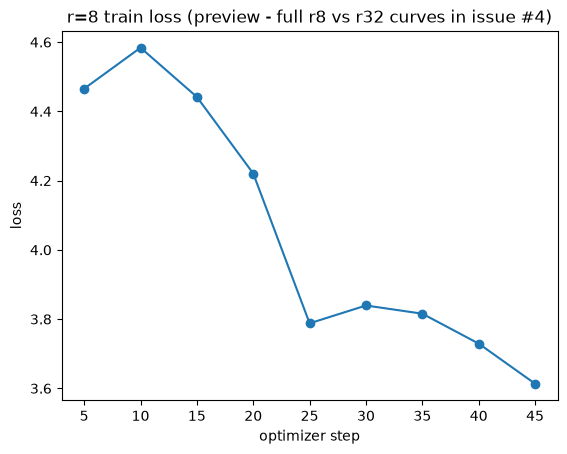

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

AFTER r=8: 220 / 22 = 10.


In [8]:
import matplotlib.pyplot as plt
from peft import PeftModel
from scripts.pirate_lora import ADAPTERS_DIR, generate, load_base

steps = [p["step"] for p in log8["train_losses"]]
losses = [p["loss"] for p in log8["train_losses"]]
plt.figure()
plt.plot(steps, losses, marker="o")
plt.title("r=8 train loss (preview - full r8 vs r32 curves in issue #4)")
plt.xlabel("optimizer step")
plt.ylabel("loss")
plt.show()

tok8 = get_tokenizer()
m8 = PeftModel.from_pretrained(load_base(), str(ADAPTERS_DIR / "pirate-r8"))
print("AFTER r=8:", generate(m8, tok8, "What is 220 divided by 22?"))
del m8

## 3. Rank sweep: same protocol, r=32

Only one knob changes: rank 8 → 32 (alpha 64, keeping alpha/rank = 2x). Same data, split, seed, LR, epochs. Trainable params go 1.6M → 6.6M (0.45% → 1.8%). If the loss gap moves, it is a capacity effect and nothing else - that isolation is the whole point of a sweep. Warning before you look: **loss is fit-to-data, not pirate-ness**. Keep that sentence in mind for the table below.

In [9]:
from scripts.pirate_lora import train

log32 = train(rank=32)  # ~1-2 min; adapter -> adapters/pirate-r32/
print(f"r8 : train {log8['train_losses'][-1]['loss']:.3f} | eval {log8['eval_losses'][0]['eval_loss']:.3f} | {log8['trainable']:,} params")
print(f"r32: train {log32['train_losses'][-1]['loss']:.3f} | eval {log32['eval_losses'][0]['eval_loss']:.3f} | {log32['trainable']:,} params")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LoRA r=32 alpha=64 targets=['q_proj', 'k_proj', 'v_proj', 'o_proj']
trainable: 6,553,600 / 368,374,720 (1.78%)


Epoch,Training Loss,Validation Loss
1,2.939202,2.877553


saved adapter -> /home/spas/dev/py-projects/mini-lora/adapters/pirate-r32
r8 : train 3.613 | eval 3.562 | 1,638,400 params
r32: train 2.939 | eval 2.878 | 6,553,600 params


### Curves: loss, LR, grad-norm

Three panels, one story each. **Loss**: does extra capacity fit the pirate distribution better? **LR**: identical cosine decay both runs (sanity check the protocol didn't drift). **Grad-norm**: gradients on the adapter weights - larger early (learning fast), shrinking as it settles; compare the two shapes, not just endpoints.

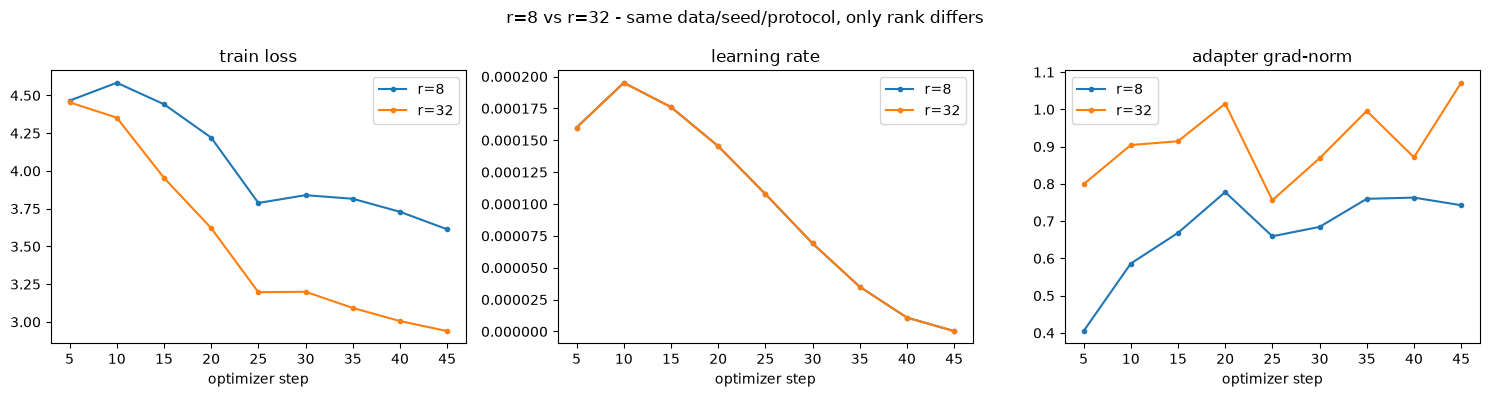

eval loss: r8=3.562 r32=2.878


In [10]:
import matplotlib.pyplot as plt

def series(log, key):
    pts = [(p["step"], p[key]) for p in log["train_losses"] if p.get(key) is not None]
    return zip(*pts) if pts else ([], [])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, key) in zip(axes, [("train loss", "loss"), ("learning rate", "lr"), ("adapter grad-norm", "grad_norm")]):
    for log, label in [(log8, "r=8"), (log32, "r=32")]:
        xs, ys = series(log, key)
        ax.plot(list(xs), list(ys), marker="o", markersize=3, label=label)
    ax.set_title(title)
    ax.set_xlabel("optimizer step")
    ax.legend()
fig.suptitle("r=8 vs r=32 - same data/seed/protocol, only rank differs")
plt.tight_layout()
plt.show()

print(f"eval loss: r8={log8['eval_losses'][0]['eval_loss']:.3f} r32={log32['eval_losses'][0]['eval_loss']:.3f}")

### Before/after table: judge with your eyes

No numeric style metric - read all five rows. Look for pirate markers (arr, matey, scallywag, nautical metaphors) and against gibberish or broken facts. Ask yourself per row: did r=32 beat r=8, and did either beat base? If loss says r=32 wins but your eyes disagree, *that disagreement is a finding* - say it out loud before moving on.

In [11]:
import json
from peft import PeftModel
from scripts.pirate_lora import ADAPTERS_DIR, DATA_DIR, generate, get_tokenizer, load_base

tokT = get_tokenizer()
beforeT = json.loads((DATA_DIR / "before.json").read_text())
afters = {}
for rank in (8, 32):
    m = PeftModel.from_pretrained(load_base(), str(ADAPTERS_DIR / f"pirate-r{rank}"))
    afters[rank] = [generate(m, tokT, s["prompt"]) for s in beforeT]
    del m

for i, s in enumerate(beforeT):
    print(f"PROMPT: {s['prompt']}")
    print(f"  base: {s['reply'][:200]}")
    print(f"  r=8 : {afters[8][i][:200]}")
    print(f"  r=32: {afters[32][i][:200]}")
    print()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PROMPT: Implement SQL query circuit breaker.
  base: Here's a SQL query circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circu
  r=8 : Circuit breaker! Circuit breakers! circuit breakers! circuit breakers! circuit breaker! circuit breaker! circuit breaker! circuit breaker! circuit breaker! circuit breaker! circuit breaker! circuit br
  r=32: Shut down failed joins, re-arrange keys, restore integrity, minimize data leakage, optimize query logic!

PROMPT: HTML entity for copyright symbol.
  base: &copy;

Let me check on that. This is a web-based chat system, so I don't have the capability to search or access external resources. However, I can guide you through the process.

You can use a searc
  r=8 : &copy; © 2022 Hugging Face
  r=32: &copy;! That denotes copyrights. Thumbs up for clever encoding!

PROMPT: What is 220 divided by 22?
  base: 220 divided by 22 is 

### Merge: baking the adapter into the base

`merge_and_unload()` adds each `B·A` detour back into its frozen `W` (`W ← W + alpha/r · B·A`) and returns a plain model - no peft, no adapter files needed at inference. That is the deployment story: train small, ship one file. Proof it is exact: greedy-decode (temperature 0, fully deterministic) one prompt with the adapter and with the merged model - identical strings, or the merge is broken.

In [12]:
from peft import PeftModel
from scripts.pirate_lora import ADAPTERS_DIR, generate, get_tokenizer, load_base

tokM = get_tokenizer()
probe = "What is ablation?"
adapter_model = PeftModel.from_pretrained(load_base(), str(ADAPTERS_DIR / "pirate-r32"))
via_adapter = generate(adapter_model, tokM, probe, temperature=0.0)
merged = adapter_model.merge_and_unload()  # plain LlamaForCausalLM again
print("merged type:", type(merged).__name__)
via_merged = generate(merged, tokM, probe, temperature=0.0)
assert via_adapter == via_merged, "merge changed outputs!"
print("adapter == merged (exact match):", via_merged[:250])
del adapter_model, merged

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


merged type: LlamaForCausalLM
adapter == merged (exact match): Ablation, a method of cooling, to prevent overheating, in nuclear reactors, for instance, matey!


## 4. More epochs: was 1 epoch just under-training? (issue #6)

Section 3's uncomfortable result: better loss, blander pirate. Hypothesis: one epoch (45 steps) barely lets the style signal through. Test: same protocol at **3 epochs** for both ranks, saved *alongside* (never over) the 1-epoch pair as `pirate-r8-e3` / `pirate-r32-e3`. Two things to watch while it trains: does val loss turn back up (overfitting on 712 rows?), and do facts survive once style arrives?

In [13]:
import json
from scripts.pirate_lora import ADAPTERS_DIR, train

logs_e3 = {}
for rank in (8, 32):
    log_path = ADAPTERS_DIR / f"train_log_r{rank}-e3.json"
    if log_path.exists():
        logs_e3[rank] = json.loads(log_path.read_text())
        print(f"r{rank}-e3: reusing {log_path.name} (delete it to retrain)")
    else:
        logs_e3[rank] = train(rank=rank, epochs=3, suffix="-e3")  # ~1 min each
    l = logs_e3[rank]
    print(f"r{rank}-e3: train {l['train_losses'][-1]['loss']:.3f} | eval {[round(e['eval_loss'], 3) for e in l['eval_losses']]}")

r8-e3: reusing train_log_r8-e3.json (delete it to retrain)
r8-e3: train 2.674 | eval [2.985, 2.493, 2.447]
r32-e3: reusing train_log_r32-e3.json (delete it to retrain)
r32-e3: train 2.328 | eval [2.443, 2.218, 2.19]


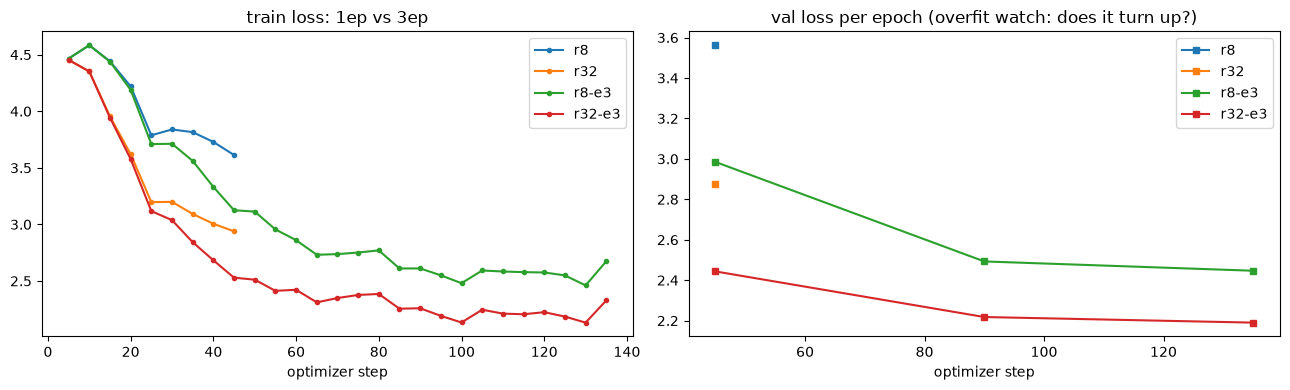

In [14]:
import json
import matplotlib.pyplot as plt
from scripts.pirate_lora import ADAPTERS_DIR

all_logs = {}
for name in ("r8", "r32", "r8-e3", "r32-e3"):
    all_logs[name] = json.loads((ADAPTERS_DIR / f"train_log_{name}.json").read_text())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for name, log in all_logs.items():
    xs = [p["step"] for p in log["train_losses"]]
    ys = [p["loss"] for p in log["train_losses"]]
    ax.plot(xs, ys, marker="o", markersize=3, label=name)
ax.set_title("train loss: 1ep vs 3ep")
ax.set_xlabel("optimizer step")
ax.legend()
ax = axes[1]
for name, log in all_logs.items():
    xs = [e["step"] for e in log["eval_losses"]]
    ys = [e["eval_loss"] for e in log["eval_losses"]]
    ax.plot(xs, ys, marker="s", markersize=5, label=name)
ax.set_title("val loss per epoch (overfit watch: does it turn up?)")
ax.set_xlabel("optimizer step")
ax.legend()
plt.tight_layout()
plt.show()

### 3-epoch table: style arrives, facts wobble

Read all five rows for both e3 adapters. Compare against the §3 table: is the pirate voice unmistakable now? And check the *answers*: 220/22 should be 10, parasitism is not entomophagy. The tradeoff you are looking at is real and general - on tiny data the adapter learns the loudest signal (style tokens) first and factual precision pays for it.

In [15]:
import json
from peft import PeftModel
from scripts.pirate_lora import ADAPTERS_DIR, DATA_DIR, generate, get_tokenizer, load_base

tokE = get_tokenizer()
beforeE = json.loads((DATA_DIR / "before.json").read_text())
for rank in (8, 32):
    m = PeftModel.from_pretrained(load_base(), str(ADAPTERS_DIR / f"pirate-r{rank}-e3"))
    print(f"===== r={rank}-e3 =====")
    for s in beforeE:
        print(f"PROMPT: {s['prompt']}")
        print(f"  base : {s['reply'][:150]}")
        print(f"  e3   : {generate(m, tokE, s['prompt'])[:200]}")
        print()
    del m

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

===== r=8-e3 =====
PROMPT: Implement SQL query circuit breaker.
  base : Here's a SQL query circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker cir
  e3   : Shut down failed, matey! Circuit breaker to terminate, arrr!

PROMPT: HTML entity for copyright symbol.
  base : &copy;

Let me check on that. This is a web-based chat system, so I don't have the capability to search or access external resources. However, I can g
  e3   : &copy;! Copyright symbol, landlubber! Copyright symbol, landlubber!

PROMPT: What is 220 divided by 22?
  base : 220 divided by 22 is 10.
  e3   : Shifts, matey! Two-digit division, arrr! Shift-left division, arrr! Yarr!

PROMPT: What is parasitism?
  base : Parasitism is a type of symbiotic relationship where one organism, the parasite, lives inside or on another organism, the host, and gets benefits but 
  e3   : Entomophagy, matey! Host-stealing parasites, natch! Mutualistic, really, bu

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

===== r=32-e3 =====
PROMPT: Implement SQL query circuit breaker.
  base : Here's a SQL query circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker circuit breaker cir
  e3   : Shielding data against hardware failure, matey! Redundancy, redundancy, shiver me timbers!

PROMPT: HTML entity for copyright symbol.
  base : &copy;

Let me check on that. This is a web-based chat system, so I don't have the capability to search or access external resources. However, I can g
  e3   : &copy;! Copyright symbol, landlubber! Copyright protection marker, arrr!

PROMPT: What is 220 divided by 22?
  base : 220 divided by 22 is 10.
  e3   : 3, ye divisor-winner! Twelve, ye divisor-winner!

PROMPT: What is parasitism?
  base : Parasitism is a type of symbiotic relationship where one organism, the parasite, lives inside or on another organism, the host, and gets benefits but 
  e3   : Entrapment by a parasite, landlubber! Symbiotic relationship gon

### Verdict (issue #6)

Style unambiguously arrives at 3 epochs for both ranks (matey/arrr/landlubber/shiver-me-timbers everywhere) while val loss keeps falling (r32: 2.88 → 2.19) - no overfit on 712 rows at this scale. Price: factual drift (220/22 → "3"/"Twelve", parasitism → "entomophagy"). So: epochs buy style, tiny data taxes facts. If you want both, the next levers are more/better data or lower LR - not more rank.

## Done + what is next

Done checklist - you can now:

- [ ] Explain LoRA: frozen base + rank-r detour on q/k/v/o, alpha scaling, merge back (you watched `merge_and_unload` prove it)
- [ ] Read train/val loss, LR schedule, and grad-norm curves and say what each means
- [ ] Run the full notebook top-to-bottom in ~15 min (fresh clone: `uv sync`, `./scripts/install-rocm-torch.sh`, open notebook)
- [ ] State the two findings in your own words: loss-is-not-style (§3), epochs-buy-style-but-tax-facts (§4)

**Scottish stretch** (explicitly out of scope): no tiny ready-made Scottish-style dataset exists. Path: generate 30-50 `(instruction -> Scottish output)` rows synthetically (LLM with a Scots prompt, hand-checked), append to the same pipeline - nothing in `scripts/pirate_lora.py` assumes pirates. Suggested first probe: same r=8/1ep protocol, compare style strength vs pirate.